# ESM MLP: Baseline, Regularization, and Hyperparameter Tuning

## Notebook goal
This notebook starts from the **ESM workflow** and keeps the same train/validation split strategy used in `MLP_ESM.ipynb`.  
It then adopts the **small-subset tuning strategy** discussed for faster hyperparameter search.

## What this notebook does
1. Load precomputed ESM embeddings and aligned GO labels  
2. Reuse the same `train_idx` / `val_idx` split from the k-mer pipeline  
3. Standardize the ESM features using training-only statistics  
4. Build the ESM dataset and shared training utilities  
5. Create small subsets for fast tuning  
6. Tune:
   - learning rate
   - dropout
   - weight decay
   - hidden layer size
7. Train a final ESM model on the full training/validation split using the selected hyperparameters  
8. Perform final threshold sweeping and save a summary

## Why use small subsets first?
Full GO prediction is computationally expensive.  
Small-subset tuning allows us to identify promising hyperparameter ranges more efficiently before running a final full-data model.


## Step 0. Imports and ESM Data Loading

### Why this step?
We first load the precomputed ESM embeddings and the aligned GO label matrix.  
This notebook assumes that the feature extraction stage has already been completed.

### What we load
- `X_esm.npy`: mean-pooled ESM embeddings
- `Y_sparse.npz` or `Y.npy`: GO target matrix
- `protein_ids.pkl`: aligned protein IDs, if available

### Why this matters
Separating feature extraction from supervised learning makes the tuning stage much faster and easier to reproduce.


In [1]:
import os
import json
import copy
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import load_npz

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

DATA_DIR = "data_processed_esm"

X_esm = np.load(os.path.join(DATA_DIR, "X_esm.npy"))
print("X_esm shape:", X_esm.shape, X_esm.dtype)

y_sparse_path = os.path.join(DATA_DIR, "Y_sparse.npz")
y_dense_path = os.path.join(DATA_DIR, "Y.npy")

if os.path.exists(y_sparse_path):
    Y = load_npz(y_sparse_path)
    print("Loaded sparse Y:", Y.shape, type(Y))
elif os.path.exists(y_dense_path):
    Y = np.load(y_dense_path)
    print("Loaded dense Y:", Y.shape, type(Y))
else:
    raise FileNotFoundError("Cannot find Y_sparse.npz or Y.npy")

protein_ids_path = os.path.join(DATA_DIR, "protein_ids.pkl")
if os.path.exists(protein_ids_path):
    with open(protein_ids_path, "rb") as f:
        protein_ids = pickle.load(f)
    print("protein_ids length:", len(protein_ids))


X_esm shape: (140569, 640) float32
Loaded sparse Y: (140569, 31454) <class 'scipy.sparse._csr.csr_matrix'>


## Step 1. Reuse the Same Train/Validation Split as `MLP_ESM`

### Why this step?
To compare models fairly, we reuse the same train/validation split strategy as the original ESM notebook:
- read `train_idx.npy`
- read `val_idx.npy`
- apply them to the aligned ESM feature matrix and GO labels

### Why this matters
This ensures that:
- the ESM tuning experiments remain consistent with the original workflow
- comparisons across models are made on the same protein samples


In [2]:
print("Number of ESM samples:", X_esm.shape[0])
print("Number of Y samples:", Y.shape[0])
assert X_esm.shape[0] == Y.shape[0], "X_esm and Y are not aligned!"

train_idx = np.load("data_processed_kmer/train_idx.npy")
val_idx   = np.load("data_processed_kmer/val_idx.npy")

X_train = X_esm[train_idx]
X_val   = X_esm[val_idx]

if hasattr(Y, "tocsr"):
    Y_train = Y[train_idx]
    Y_val   = Y[val_idx]
else:
    Y_train = Y[train_idx]
    Y_val   = Y[val_idx]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("Y_train:", Y_train.shape)
print("Y_val:  ", Y_val.shape)


Number of ESM samples: 140569
Number of Y samples: 140569
X_train: (112455, 640)
X_val:   (28114, 640)
Y_train: (112455, 31454)
Y_val:   (28114, 31454)


## Step 2. Standardize the ESM Features

### Why this step?
Even though ESM embeddings are pretrained features, standardization can still improve downstream optimization stability.

### Important design choice
The scaler is fit **only on the training set**, then applied to the validation set.
This prevents data leakage.


In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)

with open("esm_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Standardized X_train:", X_train.shape, X_train.dtype)
print("Standardized X_val:  ", X_val.shape, X_val.dtype)


Standardized X_train: (112455, 640) float32
Standardized X_val:   (28114, 640) float32


## Step 3. Define the ESM Dataset and Shared Training Components

### Why this step?
All tuning experiments will reuse the same:
- dataset class
- model class
- training loop
- evaluation loop
- threshold sweep
- experiment wrapper

### Why organize it this way?
This keeps the earlier data preparation fixed while letting us vary hyperparameters cleanly in later sections.


In [4]:
class ProteinESMDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X.astype(np.float32)
        self.Y = Y
        self.is_sparse = hasattr(Y, "tocsr")
        if self.is_sparse:
            self.Y = Y.tocsr()
            self.n_labels = self.Y.shape[1]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])

        if self.is_sparse:
            start = self.Y.indptr[idx]
            end = self.Y.indptr[idx + 1]
            pos_idx = self.Y.indices[start:end]

            y = torch.zeros(self.n_labels, dtype=torch.float32)
            y[pos_idx] = 1.0
        else:
            y = torch.tensor(self.Y[idx], dtype=torch.float32)

        return x, y


train_dataset = ProteinESMDataset(X_train, Y_train)
val_dataset   = ProteinESMDataset(X_val, Y_val)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]

print("Device:", device)
print("Input dim:", input_dim)
print("Output dim:", output_dim)


Device: cpu
Input dim: 640
Output dim: 31454


/global/home/users/yushanfu/esm_env/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
class ESMMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden1=512, hidden2=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.net(x)


if hasattr(Y_train, "sum") and not isinstance(Y_train, np.ndarray):
    label_counts = np.asarray(Y_train.sum(axis=0)).ravel().astype(np.float32)
else:
    label_counts = Y_train.sum(axis=0).astype(np.float32)

n_train = Y_train.shape[0]
pos_weight = (n_train - label_counts) / (label_counts + 1e-6)
pos_weight = np.clip(pos_weight, 1.0, 100.0)

print("label_counts shape:", label_counts.shape)
print("pos_weight min/max:", pos_weight.min(), pos_weight.max())

pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


label_counts shape: (31454,)
pos_weight min/max: 1.0 100.0


In [6]:
def build_dataloaders(train_dataset, val_dataset, batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )
    return train_loader, val_loader


def build_model(config, input_dim, output_dim, device):
    return ESMMLP(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"]
    ).to(device)


def build_optimizer(model, config):
    return optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, Y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, Y_batch)

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(Y_batch.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    return all_probs, all_targets


def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.1)

    records = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        records.append({
            "threshold": float(t),
            "micro_f1": float(micro),
            "macro_f1": float(macro)
        })

    best_micro_row = max(records, key=lambda x: x["micro_f1"])
    best_macro_row = max(records, key=lambda x: x["macro_f1"])
    return records, best_micro_row, best_macro_row


def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, device,
                              num_epochs=10, patience=3, save_path=None):
    best_val_loss = float("inf")
    best_state_dict = None
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0

            if save_path is not None:
                torch.save(best_state_dict, save_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, train_losses, val_losses, best_val_loss


def run_experiment(config, train_dataset, val_dataset, input_dim, output_dim, criterion, device,
                   run_threshold_sweep=True):
    train_loader, val_loader = build_dataloaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=config["batch_size"]
    )

    model = build_model(config, input_dim, output_dim, device)
    optimizer = build_optimizer(model, config)
    save_path = f"{config['save_prefix']}.pt"

    model, train_losses, val_losses, best_val_loss = train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=config["num_epochs"],
        patience=config["patience"],
        save_path=save_path
    )

    result = {
        "config": config.copy(),
        "model": model,
        "model_path": save_path,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

    if run_threshold_sweep:
        val_probs, val_targets = get_predictions(model, val_loader, device)
        records, best_micro_row, best_macro_row = threshold_sweep(val_targets, val_probs)
        result["threshold_records"] = records
        result["best_micro_row"] = best_micro_row
        result["best_macro_row"] = best_macro_row

    return result


## Step 4. Build Small Subsets for Fast Tuning

### Why this step?
Full-data tuning is expensive.  
We therefore create smaller subsets of the training and validation data to run faster coarse experiments.

### Important note
These subset experiments are used to identify promising hyperparameter settings, not to produce the final reported model.


In [7]:
np.random.seed(42)

small_train_size = len(train_dataset) // 10
small_val_size = len(val_dataset) // 10

small_train_idx = np.random.choice(len(train_dataset), size=small_train_size, replace=False)
small_val_idx = np.random.choice(len(val_dataset), size=small_val_size, replace=False)

train_dataset_small = Subset(train_dataset, small_train_idx)
val_dataset_small = Subset(val_dataset, small_val_idx)

print("Full train size:", len(train_dataset))
print("Full val size:", len(val_dataset))
print("Small train size:", len(train_dataset_small))
print("Small val size:", len(val_dataset_small))


Full train size: 112455
Full val size: 28114
Small train size: 11245
Small val size: 2811


## Step 5. Quick Baseline Sanity Check on Small Subsets

### Why this step?
Before running full tuning loops, we perform a short sanity check to verify that:
- the ESM pipeline runs correctly
- the loss stays finite
- checkpointing and dataloaders behave as expected

### Important note
We keep this short and do **not** use it as the final reported model.


In [8]:
ESM_BASELINE_CONFIG = {
    "hidden1": 512,
    "hidden2": 256,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 64,
    "num_epochs": 3,
    "patience": 2,
    "save_prefix": "esm_baseline_small"
}

baseline_result_esm = run_experiment(
    config=ESM_BASELINE_CONFIG,
    train_dataset=train_dataset_small,
    val_dataset=val_dataset_small,
    input_dim=input_dim,
    output_dim=output_dim,
    criterion=criterion,
    device=device,
    run_threshold_sweep=False
)

print("ESM baseline best val loss:", baseline_result_esm["best_val_loss"])
print("ESM baseline model path:", baseline_result_esm["model_path"])


Epoch 01/3 | train_loss=0.181280 | val_loss=0.127801
Epoch 02/3 | train_loss=0.119930 | val_loss=0.116648
Epoch 03/3 | train_loss=0.109776 | val_loss=0.111840
ESM baseline best val loss: 0.11183971539139748
ESM baseline model path: esm_baseline_small.pt


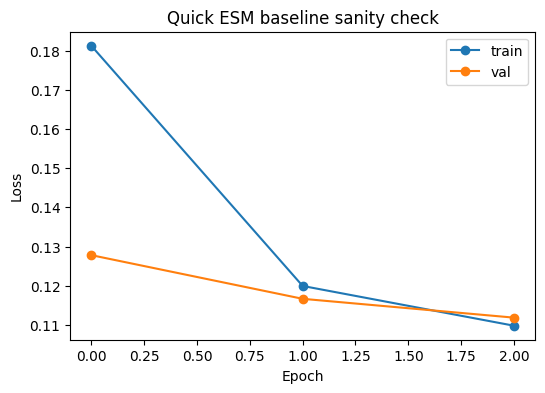

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(baseline_result_esm["train_losses"], marker="o", label="train")
plt.plot(baseline_result_esm["val_losses"], marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Quick ESM baseline sanity check")
plt.legend()
plt.show()


## Step 6. Hyperparameter Tuning: Learning Rate

### Why this step?
We tune the learning rate first because it strongly affects optimization stability and convergence speed.

### What is fixed in this section?
We keep the architecture and regularization settings fixed, and only vary:
- `learning_rate`

### Selection rule
For each run, we perform threshold sweeping on the validation subset and select the best learning rate using **best micro-F1**.


In [10]:
ESM_TUNING_BASE_CONFIG = {
    "hidden1": 512,
    "hidden2": 256,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 64,
    "num_epochs": 3,
    "patience": 3,
    "save_prefix": "esm_tuning_run"
}

learning_rates = [1e-2, 1e-3, 1e-4]
lr_results_esm = []

for lr in learning_rates:
    print("=" * 80)
    print(f"ESM learning rate tuning: lr = {lr}")
    print("=" * 80)

    config = ESM_TUNING_BASE_CONFIG.copy()
    config["learning_rate"] = lr
    config["save_prefix"] = f"esm_lr_{lr}"

    result = run_experiment(
        config=config,
        train_dataset=train_dataset_small,
        val_dataset=val_dataset_small,
        input_dim=input_dim,
        output_dim=output_dim,
        criterion=criterion,
        device=device,
        run_threshold_sweep=True
    )

    lr_results_esm.append({
        "learning_rate": lr,
        "best_val_loss": result["best_val_loss"],
        "best_micro_f1": result["best_micro_row"]["micro_f1"],
        "best_macro_f1": result["best_micro_row"]["macro_f1"],
        "best_threshold_micro": result["best_micro_row"]["threshold"],
        "model_path": result["model_path"]
    })

df_lr_esm = pd.DataFrame(lr_results_esm).sort_values("best_micro_f1", ascending=False).reset_index(drop=True)
display(df_lr_esm)


ESM learning rate tuning: lr = 0.01
Epoch 01/3 | train_loss=0.156106 | val_loss=0.138144
Epoch 02/3 | train_loss=0.138327 | val_loss=0.134944
Epoch 03/3 | train_loss=0.135681 | val_loss=0.133262
ESM learning rate tuning: lr = 0.001
Epoch 01/3 | train_loss=0.181230 | val_loss=0.129160
Epoch 02/3 | train_loss=0.120129 | val_loss=0.117521
Epoch 03/3 | train_loss=0.109869 | val_loss=0.111661
ESM learning rate tuning: lr = 0.0001
Epoch 01/3 | train_loss=0.484163 | val_loss=0.342315
Epoch 02/3 | train_loss=0.239764 | val_loss=0.213064
Epoch 03/3 | train_loss=0.173557 | val_loss=0.169911


,learning_rate,best_val_loss,best_micro_f1,best_macro_f1,best_threshold_micro,model_path
0,0.0010,0.111661,0.156353,0.007186,0.75,esm_lr_0.001.pt
1,0.0001,0.169911,0.139197,0.002980,0.55,esm_lr_0.0001.pt
2,0.0100,0.133262,0.083634,0.005785,0.65,esm_lr_0.01.pt


In [11]:
best_lr_row_esm = df_lr_esm.iloc[0]
best_learning_rate_esm = float(best_lr_row_esm["learning_rate"])

print("Best ESM learning rate:", best_learning_rate_esm)
print("Best ESM LR row:")
display(best_lr_row_esm.to_frame())


Best ESM learning rate: 0.001
Best ESM LR row:


,0
learning_rate,0.001
best_val_loss,0.111661
best_micro_f1,0.156353
best_macro_f1,0.007186
best_threshold_micro,0.75
model_path,esm_lr_0.001.pt


## Step 7. Regularization Strategy 1: Dropout

### Why this step?
Dropout is a standard regularization technique that reduces overfitting by randomly masking hidden units during training.

### What is fixed in this section?
We fix the best learning rate from the previous step and vary:
- `dropout`


In [12]:
dropout_values = [0.0, 0.3, 0.5]
dropout_results_esm = []

for dp in dropout_values:
    print("=" * 80)
    print(f"ESM dropout tuning: dropout = {dp}")
    print("=" * 80)

    config = ESM_TUNING_BASE_CONFIG.copy()
    config["learning_rate"] = best_learning_rate_esm
    config["dropout"] = dp
    config["save_prefix"] = f"esm_dropout_{dp}"

    result = run_experiment(
        config=config,
        train_dataset=train_dataset_small,
        val_dataset=val_dataset_small,
        input_dim=input_dim,
        output_dim=output_dim,
        criterion=criterion,
        device=device,
        run_threshold_sweep=True
    )

    dropout_results_esm.append({
        "dropout": dp,
        "learning_rate": best_learning_rate_esm,
        "best_val_loss": result["best_val_loss"],
        "best_micro_f1": result["best_micro_row"]["micro_f1"],
        "best_macro_f1": result["best_micro_row"]["macro_f1"],
        "best_threshold_micro": result["best_micro_row"]["threshold"],
        "model_path": result["model_path"]
    })

df_dropout_esm = pd.DataFrame(dropout_results_esm).sort_values("best_micro_f1", ascending=False).reset_index(drop=True)
display(df_dropout_esm)


ESM dropout tuning: dropout = 0.0
Epoch 01/3 | train_loss=0.173562 | val_loss=0.123479
Epoch 02/3 | train_loss=0.113475 | val_loss=0.115382
Epoch 03/3 | train_loss=0.102288 | val_loss=0.108750
ESM dropout tuning: dropout = 0.3
Epoch 01/3 | train_loss=0.181455 | val_loss=0.126710
Epoch 02/3 | train_loss=0.120110 | val_loss=0.116311
Epoch 03/3 | train_loss=0.109736 | val_loss=0.112144
ESM dropout tuning: dropout = 0.5
Epoch 01/3 | train_loss=0.190585 | val_loss=0.134550
Epoch 02/3 | train_loss=0.127949 | val_loss=0.122496
Epoch 03/3 | train_loss=0.117981 | val_loss=0.116111


,dropout,learning_rate,best_val_loss,best_micro_f1,best_macro_f1,best_threshold_micro,model_path
0,0.3,0.001,0.112144,0.151040,0.007141,0.65,esm_dropout_0.3.pt
1,0.0,0.001,0.108750,0.149645,0.008413,0.75,esm_dropout_0.0.pt
2,0.5,0.001,0.116111,0.134258,0.005917,0.65,esm_dropout_0.5.pt


In [13]:
best_dropout_row_esm = df_dropout_esm.iloc[0]
best_dropout_esm = float(best_dropout_row_esm["dropout"])

print("Best ESM dropout:", best_dropout_esm)
print("Best ESM dropout row:")
display(best_dropout_row_esm.to_frame())


Best ESM dropout: 0.3
Best ESM dropout row:


,0
dropout,0.3
learning_rate,0.001
best_val_loss,0.112144
best_micro_f1,0.15104
best_macro_f1,0.007141
best_threshold_micro,0.65
model_path,esm_dropout_0.3.pt


## Step 8. Regularization Strategy 2: Weight Decay

### Why this step?
Weight decay implements L2 regularization, which discourages overly large weights and can improve generalization.

### What is fixed in this section?
We fix:
- the best learning rate
- the best dropout setting

We then vary:
- `weight_decay`


In [14]:
weight_decay_values = [0.0, 1e-5, 1e-4]
wd_results_esm = []

for wd in weight_decay_values:
    print("=" * 80)
    print(f"ESM weight decay tuning: wd = {wd}")
    print("=" * 80)

    config = ESM_TUNING_BASE_CONFIG.copy()
    config["learning_rate"] = best_learning_rate_esm
    config["dropout"] = best_dropout_esm
    config["weight_decay"] = wd
    config["save_prefix"] = f"esm_wd_{wd}"

    result = run_experiment(
        config=config,
        train_dataset=train_dataset_small,
        val_dataset=val_dataset_small,
        input_dim=input_dim,
        output_dim=output_dim,
        criterion=criterion,
        device=device,
        run_threshold_sweep=True
    )

    wd_results_esm.append({
        "weight_decay": wd,
        "learning_rate": best_learning_rate_esm,
        "dropout": best_dropout_esm,
        "best_val_loss": result["best_val_loss"],
        "best_micro_f1": result["best_micro_row"]["micro_f1"],
        "best_macro_f1": result["best_micro_row"]["macro_f1"],
        "best_threshold_micro": result["best_micro_row"]["threshold"],
        "model_path": result["model_path"]
    })

df_wd_esm = pd.DataFrame(wd_results_esm).sort_values("best_micro_f1", ascending=False).reset_index(drop=True)
display(df_wd_esm)


ESM weight decay tuning: wd = 0.0
Epoch 01/3 | train_loss=0.177957 | val_loss=0.119755
Epoch 02/3 | train_loss=0.111438 | val_loss=0.110954
Epoch 03/3 | train_loss=0.099386 | val_loss=0.106917
ESM weight decay tuning: wd = 1e-05
Epoch 01/3 | train_loss=0.181319 | val_loss=0.127462
Epoch 02/3 | train_loss=0.120076 | val_loss=0.115844
Epoch 03/3 | train_loss=0.109798 | val_loss=0.111792
ESM weight decay tuning: wd = 0.0001
Epoch 01/3 | train_loss=0.253465 | val_loss=0.186209
Epoch 02/3 | train_loss=0.175128 | val_loss=0.167766
Epoch 03/3 | train_loss=0.159828 | val_loss=0.155417


,weight_decay,learning_rate,dropout,best_val_loss,best_micro_f1,best_macro_f1,best_threshold_micro,model_path
0,0.00000,0.001,0.3,0.106917,0.159606,0.007095,0.75,esm_wd_0.0.pt
1,0.00001,0.001,0.3,0.111792,0.148148,0.007200,0.75,esm_wd_1e-05.pt
2,0.00010,0.001,0.3,0.155417,0.138748,0.003919,0.65,esm_wd_0.0001.pt


In [15]:
best_wd_row_esm = df_wd_esm.iloc[0]
best_weight_decay_esm = float(best_wd_row_esm["weight_decay"])

print("Best ESM weight decay:", best_weight_decay_esm)
print("Best ESM weight decay row:")
display(best_wd_row_esm.to_frame())


Best ESM weight decay: 0.0
Best ESM weight decay row:


,0
weight_decay,0.0
learning_rate,0.001
dropout,0.3
best_val_loss,0.106917
best_micro_f1,0.159606
best_macro_f1,0.007095
best_threshold_micro,0.75
model_path,esm_wd_0.0.pt


## Step 9. Hidden Layer Size Tuning

### Why this step?
Hidden layer size controls model capacity.  
A model that is too small may underfit, while a model that is too large may overfit.

### What we test
We compare several hidden-layer configurations while keeping the previously selected learning rate, dropout, and weight decay fixed.


In [16]:
hidden_configs = [
    (256, 128),
    (512, 256),
    (1024, 512)
]

hidden_results_esm = []

for h1, h2 in hidden_configs:
    print("=" * 80)
    print(f"ESM hidden layer tuning: hidden1 = {h1}, hidden2 = {h2}")
    print("=" * 80)

    config = ESM_TUNING_BASE_CONFIG.copy()
    config["learning_rate"] = best_learning_rate_esm
    config["dropout"] = best_dropout_esm
    config["weight_decay"] = best_weight_decay_esm
    config["hidden1"] = h1
    config["hidden2"] = h2
    config["save_prefix"] = f"esm_hidden_{h1}_{h2}"

    result = run_experiment(
        config=config,
        train_dataset=train_dataset_small,
        val_dataset=val_dataset_small,
        input_dim=input_dim,
        output_dim=output_dim,
        criterion=criterion,
        device=device,
        run_threshold_sweep=True
    )

    hidden_results_esm.append({
        "hidden1": h1,
        "hidden2": h2,
        "learning_rate": best_learning_rate_esm,
        "dropout": best_dropout_esm,
        "weight_decay": best_weight_decay_esm,
        "best_val_loss": result["best_val_loss"],
        "best_micro_f1": result["best_micro_row"]["micro_f1"],
        "best_macro_f1": result["best_micro_row"]["macro_f1"],
        "best_threshold_micro": result["best_micro_row"]["threshold"],
        "model_path": result["model_path"]
    })

df_hidden_esm = pd.DataFrame(hidden_results_esm).sort_values("best_micro_f1", ascending=False).reset_index(drop=True)
display(df_hidden_esm)


ESM hidden layer tuning: hidden1 = 256, hidden2 = 128
Epoch 01/3 | train_loss=0.223920 | val_loss=0.127228
Epoch 02/3 | train_loss=0.119406 | val_loss=0.115267
Epoch 03/3 | train_loss=0.108338 | val_loss=0.110938
ESM hidden layer tuning: hidden1 = 512, hidden2 = 256
Epoch 01/3 | train_loss=0.177665 | val_loss=0.118534
Epoch 02/3 | train_loss=0.111196 | val_loss=0.110919
Epoch 03/3 | train_loss=0.099246 | val_loss=0.107105
ESM hidden layer tuning: hidden1 = 1024, hidden2 = 512
Epoch 01/3 | train_loss=0.154973 | val_loss=0.116322
Epoch 02/3 | train_loss=0.105193 | val_loss=0.109093
Epoch 03/3 | train_loss=0.091802 | val_loss=0.106286


,hidden1,hidden2,learning_rate,dropout,weight_decay,best_val_loss,best_micro_f1,best_macro_f1,best_threshold_micro,model_path
0,1024,512,0.001,0.3,0.0,0.106286,0.158863,0.009113,0.75,esm_hidden_1024_512.pt
1,512,256,0.001,0.3,0.0,0.107105,0.156113,0.007051,0.75,esm_hidden_512_256.pt
2,256,128,0.001,0.3,0.0,0.110938,0.145915,0.005883,0.65,esm_hidden_256_128.pt


In [17]:
best_hidden_row_esm = df_hidden_esm.iloc[0]
best_hidden1_esm = int(best_hidden_row_esm["hidden1"])
best_hidden2_esm = int(best_hidden_row_esm["hidden2"])

print("Best ESM hidden layer:")
print(f"hidden1 = {best_hidden1_esm}, hidden2 = {best_hidden2_esm}")
print("Best ESM hidden row:")
display(best_hidden_row_esm.to_frame())


Best ESM hidden layer:
hidden1 = 1024, hidden2 = 512
Best ESM hidden row:


,0
hidden1,1024
hidden2,512
learning_rate,0.001
dropout,0.3
weight_decay,0.0
best_val_loss,0.106286
best_micro_f1,0.158863
best_macro_f1,0.009113
best_threshold_micro,0.75
model_path,esm_hidden_1024_512.pt


## Step 10. Final Full-Data ESM Model

### Why this step?
After tuning on small subsets, we train a final ESM model on the full training and validation split using the selected hyperparameters.

### Why this matters
This final stage provides the main model and threshold-based validation results to report.


In [18]:
FINAL_CONFIG_ESM = ESM_TUNING_BASE_CONFIG.copy()
FINAL_CONFIG_ESM["learning_rate"] = best_learning_rate_esm
FINAL_CONFIG_ESM["dropout"] = best_dropout_esm
FINAL_CONFIG_ESM["weight_decay"] = best_weight_decay_esm
FINAL_CONFIG_ESM["hidden1"] = best_hidden1_esm
FINAL_CONFIG_ESM["hidden2"] = best_hidden2_esm
FINAL_CONFIG_ESM["num_epochs"] = 5
FINAL_CONFIG_ESM["patience"] = 3
FINAL_CONFIG_ESM["save_prefix"] = "esm_final_full"

print("Final ESM config:")
print(FINAL_CONFIG_ESM)


Final ESM config:
{'hidden1': 1024, 'hidden2': 512, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0, 'batch_size': 64, 'num_epochs': 5, 'patience': 3, 'save_prefix': 'esm_final_full'}


In [19]:
final_result_esm = run_experiment(
    config=FINAL_CONFIG_ESM,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    output_dim=output_dim,
    criterion=criterion,
    device=device,
    run_threshold_sweep=True
)

print("Final ESM best val loss:", final_result_esm["best_val_loss"])
print("Final ESM best micro-F1:", final_result_esm["best_micro_row"])
print("Final ESM best macro-F1:", final_result_esm["best_macro_row"])
print("Final ESM model path:", final_result_esm["model_path"])


Epoch 01/5 | train_loss=0.106480 | val_loss=0.090530
Epoch 02/5 | train_loss=0.086398 | val_loss=0.084321
Epoch 03/5 | train_loss=0.079381 | val_loss=0.081538
Epoch 04/5 | train_loss=0.074217 | val_loss=0.079733
Epoch 05/5 | train_loss=0.070544 | val_loss=0.078217
Final ESM best val loss: 0.07821710324761542
Final ESM best micro-F1: {'threshold': 0.7500000000000002, 'micro_f1': 0.2012154299395264, 'macro_f1': 0.06214149901078674}
Final ESM best macro-F1: {'threshold': 0.7500000000000002, 'micro_f1': 0.2012154299395264, 'macro_f1': 0.06214149901078674}
Final ESM model path: esm_final_full.pt


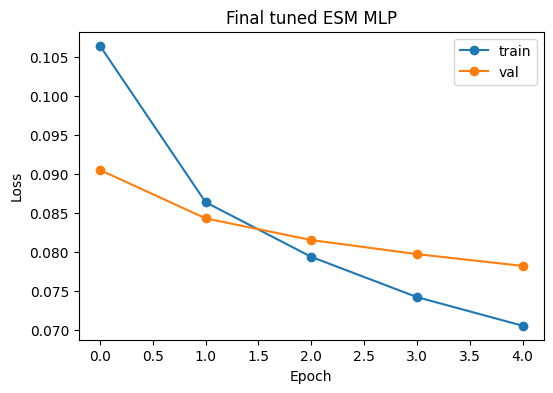

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(final_result_esm["train_losses"], marker="o", label="train")
plt.plot(final_result_esm["val_losses"], marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final tuned ESM MLP")
plt.legend()
plt.show()


,threshold,micro_f1,macro_f1
0,0.05,0.026964,0.010162
1,0.15,0.047896,0.017013
2,0.25,0.068577,0.025308
3,0.35,0.091867,0.035120
4,0.45,0.118843,0.045235
5,0.55,0.149220,0.054586
6,0.65,0.178755,0.060264
7,0.75,0.201215,0.062141
8,0.85,0.194988,0.053569


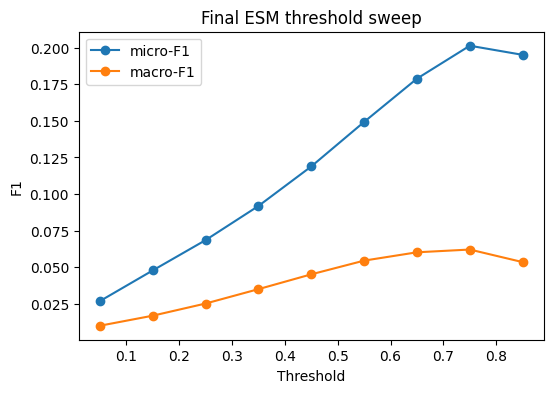

In [21]:
df_thresh_esm = pd.DataFrame(final_result_esm["threshold_records"])
display(df_thresh_esm)

plt.figure(figsize=(6, 4))
plt.plot(df_thresh_esm["threshold"], df_thresh_esm["micro_f1"], marker="o", label="micro-F1")
plt.plot(df_thresh_esm["threshold"], df_thresh_esm["macro_f1"], marker="o", label="macro-F1")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("Final ESM threshold sweep")
plt.legend()
plt.show()


## Step 11. Save the Selected Hyperparameters and Final Results

### Why this step?
Saving the selected settings and final metrics makes the ESM tuning pipeline reproducible and easier to compare with the k-mer notebook.


In [22]:
summary_esm = {
    "best_learning_rate": best_learning_rate_esm,
    "best_dropout": best_dropout_esm,
    "best_weight_decay": best_weight_decay_esm,
    "best_hidden1": best_hidden1_esm,
    "best_hidden2": best_hidden2_esm,
    "final_best_val_loss": float(final_result_esm["best_val_loss"]),
    "final_best_micro": final_result_esm["best_micro_row"],
    "final_best_macro": final_result_esm["best_macro_row"],
    "final_model_path": final_result_esm["model_path"],
}

with open("esm_tuning_summary.json", "w") as f:
    json.dump(summary_esm, f, indent=2)

print("Saved tuning summary to esm_tuning_summary.json")
print(summary_esm)


Saved tuning summary to esm_tuning_summary.json
{'best_learning_rate': 0.001, 'best_dropout': 0.3, 'best_weight_decay': 0.0, 'best_hidden1': 1024, 'best_hidden2': 512, 'final_best_val_loss': 0.07821710324761542, 'final_best_micro': {'threshold': 0.7500000000000002, 'micro_f1': 0.2012154299395264, 'macro_f1': 0.06214149901078674}, 'final_best_macro': {'threshold': 0.7500000000000002, 'micro_f1': 0.2012154299395264, 'macro_f1': 0.06214149901078674}, 'final_model_path': 'esm_final_full.pt'}


## Summary and Interpretation

### What this notebook accomplished
This notebook starts from the original ESM train/validation split strategy and then adopts the small-subset tuning workflow to make hyperparameter search more practical.

### What was tuned
We tuned:
- learning rate
- dropout
- weight decay
- hidden layer size

### Final outcome
The selected hyperparameters were then transferred to a final full-data ESM model, followed by threshold sweeping on the validation set.

### Why this workflow is useful
This preserves consistency with the original ESM pipeline while making tuning substantially more efficient.
